In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("household_cleandata.csv")

In [4]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Day_Name,Month_Name,Year,Hours,Minutes,Total_metering
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,Saturday,December,2006,17,24,18.0
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,Saturday,December,2006,17,25,17.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,Saturday,December,2006,17,26,19.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,Saturday,December,2006,17,27,18.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,Saturday,December,2006,17,28,18.0


In [5]:
### analysis

In [6]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'Day_Name', 'Month_Name', 'Year', 'Hours', 'Minutes',
       'Total_metering'],
      dtype='str')

#### checking the distribution for 'Global_active_power', 'Global_reactive_power',
#### 'Voltage', 'Global_intensity','Total_metering'

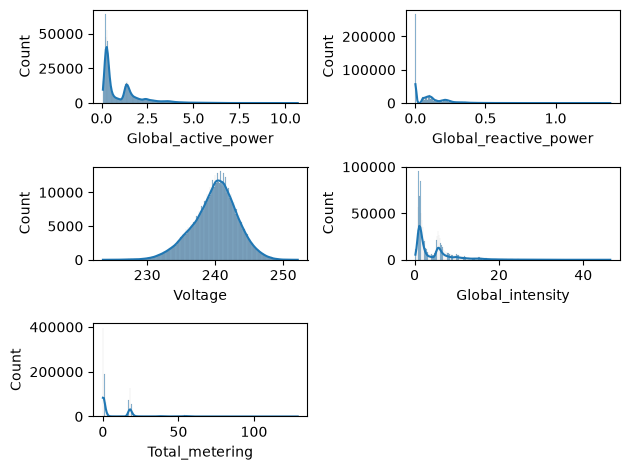

In [7]:
hist = ['Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity','Total_metering']
pos = 1
for i in hist:
    plt.subplot(3,2,pos)
    sns.histplot(df[i],kde = True)
    pos+=1
plt.tight_layout()
plt.show()

In [8]:
## bivariate analysis
## year wise total and average consumption

In [9]:
df.groupby('Year').agg(total = ('Total_metering','sum'),Avg = ('Total_metering','mean')).reset_index()

,Year,total,Avg
0,2006,239123.0,10.873181
1,2007,4519748.0,8.664015
2,2008,4209743.0,8.405281


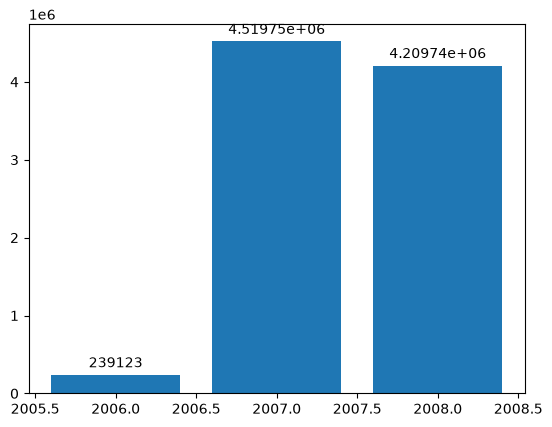

In [10]:
# year wise total consumption
x = df.groupby('Year')['Total_metering'].sum().index
y = df.groupby('Year')['Total_metering'].sum().values
bars = plt.bar(x,y)
plt.bar_label(bars,padding = 3)
plt.show()

##### Year,month_name,dayname and hour wise total consumption

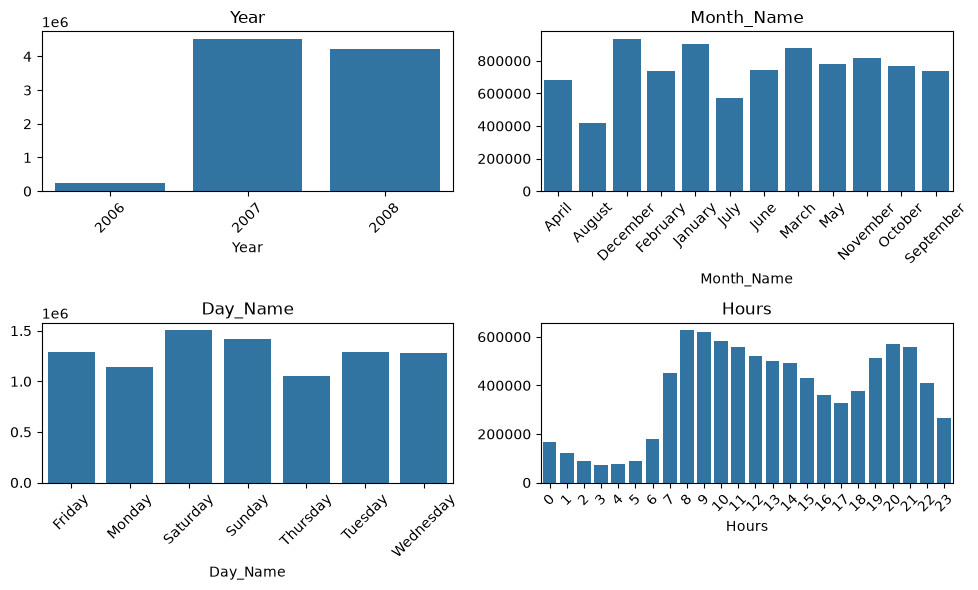

In [17]:
plt.figure(figsize=(10,6))

pos=1

cat_2 = ['Year', 'Month_Name','Day_Name', 'Hours']

for i in cat_2:
     plt.subplot(2,2,pos)
     x = df.groupby(i)['Total_metering'].sum().index

     y = df.groupby(i)['Total_metering'].sum().values

     sns.barplot(x=x,y=y) 

     pos+=1

     plt.xticks(rotation = 45)
     plt.title(i)

plt.tight_layout()

plt.show() 


##### Year,month_name,dayname and hour wise Global_active_power

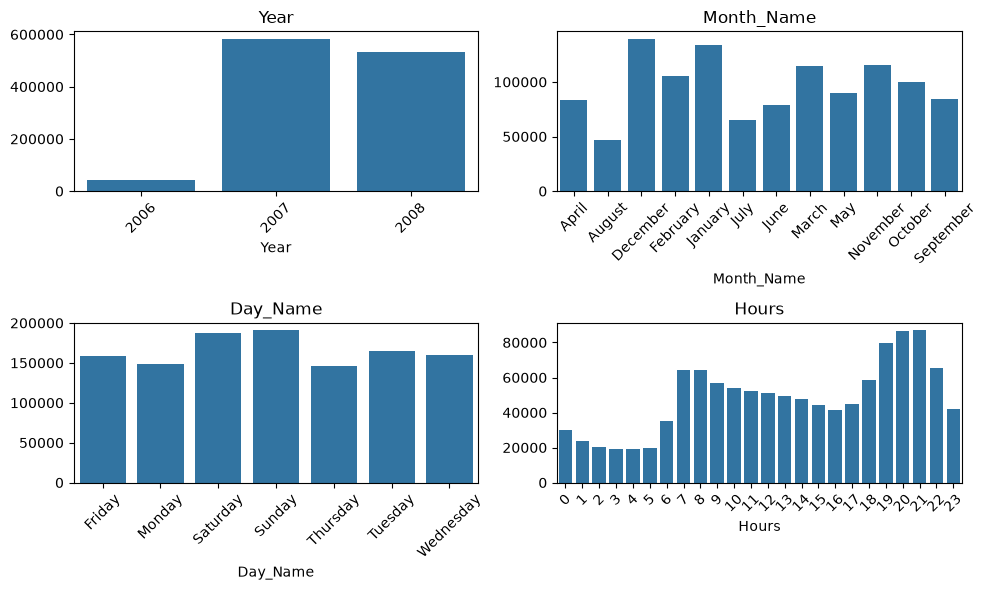

In [18]:
plt.figure(figsize=(10,6))
pos=1
cat_2 = ['Year', 'Month_Name','Day_Name', 'Hours']
for i in cat_2:
    plt.subplot(2,2,pos)
    x = df.groupby(i)['Global_active_power'].sum().index
    y = df.groupby(i)['Global_active_power'].sum().values
    sns.barplot(x=x,y=y) 
    pos+=1
    plt.xticks(rotation = 45)
    plt.title(i)
plt.tight_layout()
plt.show() 

##### Year,month_name,dayname and hour wise Global_reactive_power

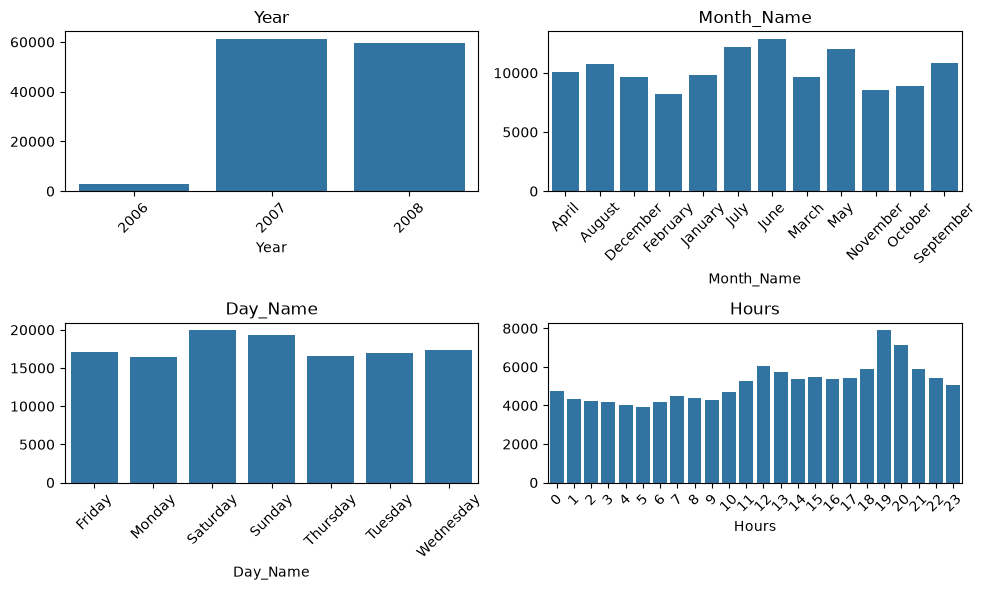

In [19]:
plt.figure(figsize=(10,6))
pos=1
cat_2 = ['Year', 'Month_Name','Day_Name', 'Hours']
for i in cat_2:
    plt.subplot(2,2,pos)
    x = df.groupby(i)['Global_reactive_power'].sum().index
    y = df.groupby(i)['Global_reactive_power'].sum().values
    sns.barplot(x=x,y=y) 
    pos+=1
    plt.xticks(rotation = 45)
    plt.title(i)
plt.tight_layout()
plt.show() 

##### Year,month_name,dayname and hour wise Voltage

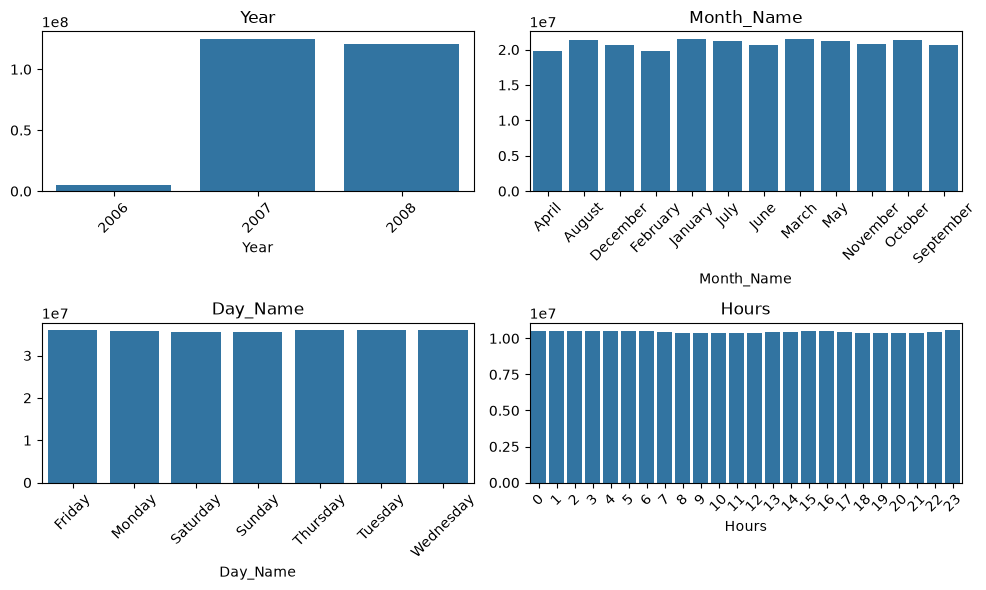

In [21]:
plt.figure(figsize=(10,6))
pos=1
cat_2 = ['Year', 'Month_Name','Day_Name', 'Hours']
for i in cat_2:
    plt.subplot(2,2,pos)
    x = df.groupby(i)['Voltage'].sum().index
    y = df.groupby(i)['Voltage'].sum().values
    sns.barplot(x=x,y=y) 
    
    pos+=1
    plt.xticks(rotation = 45)
    plt.title(i)
plt.tight_layout()
plt.show() 

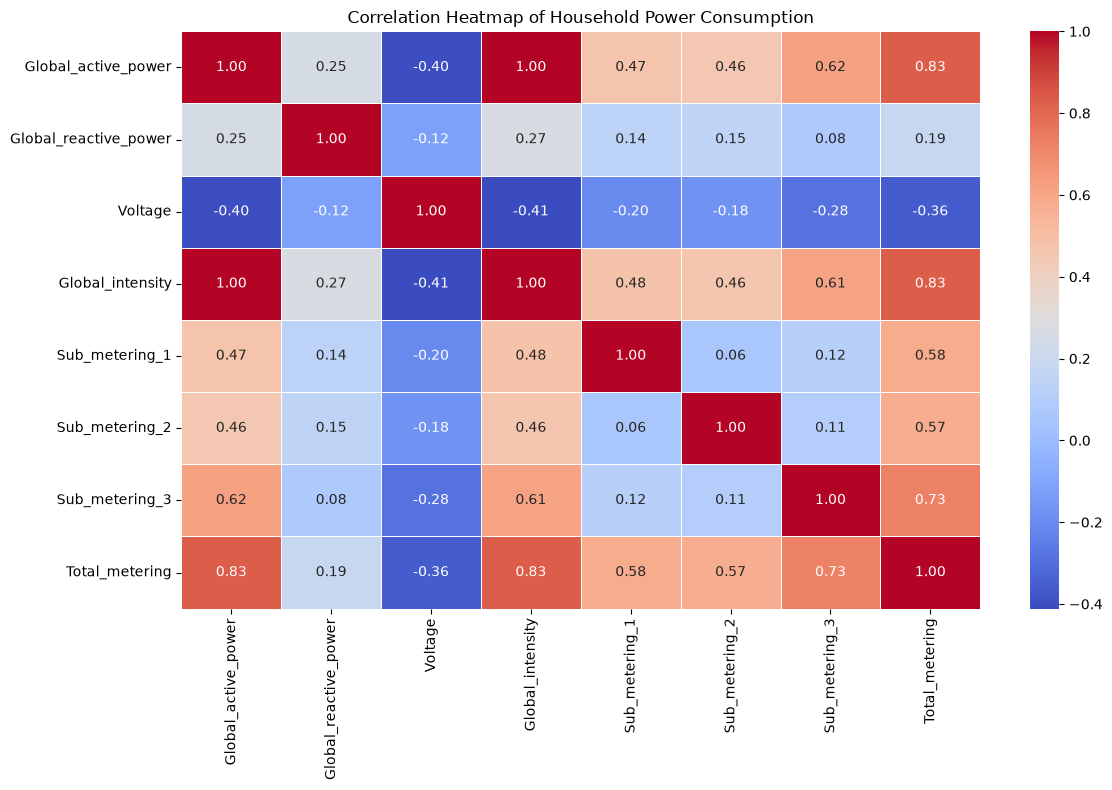

In [22]:
corr_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3',
    'Total_metering'
]

plt.figure(figsize=(12,8))

corr = df[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Household Power Consumption")

plt.tight_layout()
plt.show()

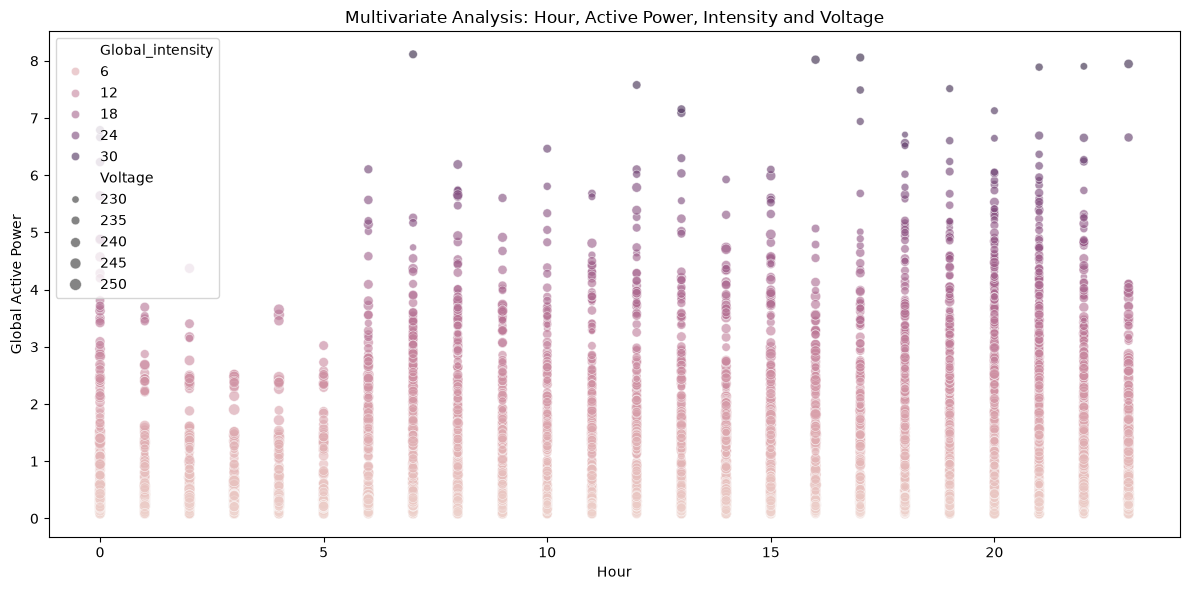

In [23]:
sample_df = df.sample(10000, random_state=42)

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=sample_df,
    x='Hours',
    y='Global_active_power',
    hue='Global_intensity',
    size='Voltage',
    alpha=0.6
)

plt.title("Multivariate Analysis: Hour, Active Power, Intensity and Voltage")
plt.xlabel("Hour")
plt.ylabel("Global Active Power")

plt.tight_layout()
plt.show()

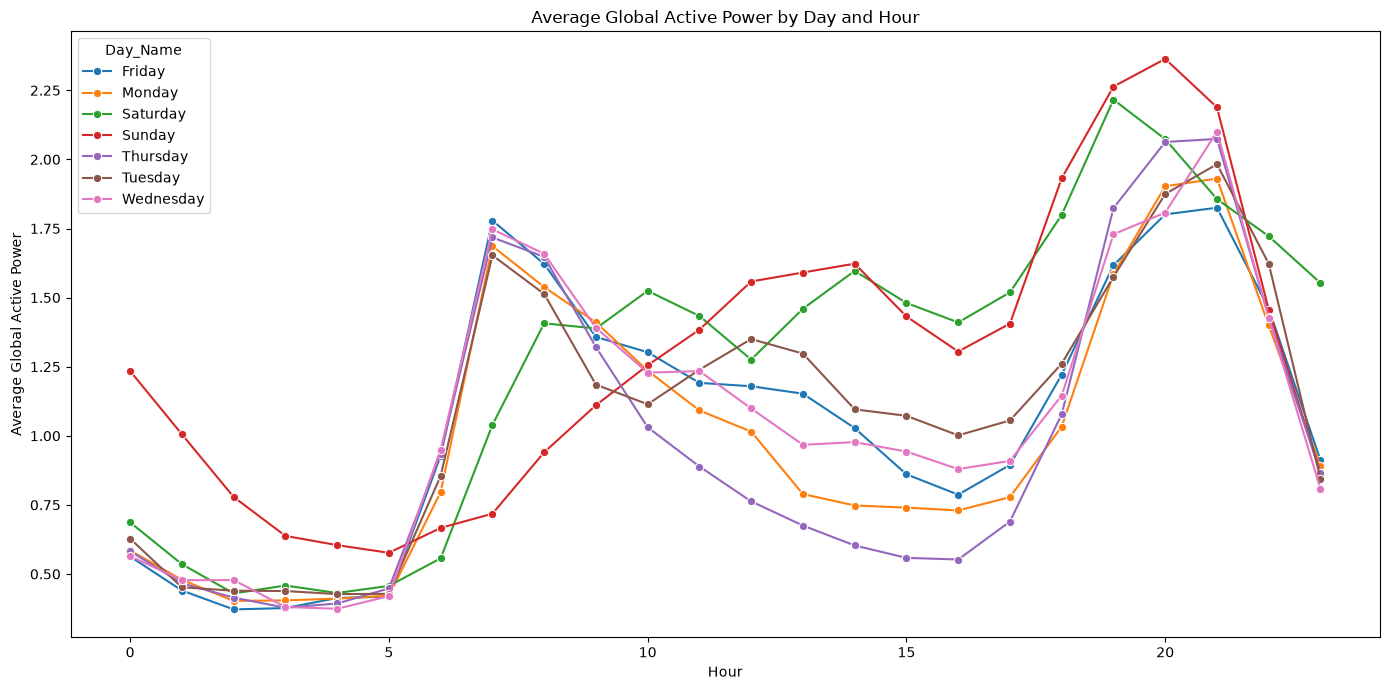

In [24]:
hour_day = (
    df.groupby(['Day_Name', 'Hours'])['Global_active_power']
      .mean()
      .reset_index()
)

plt.figure(figsize=(14,7))

sns.lineplot(
    data=hour_day,
    x='Hours',
    y='Global_active_power',
    hue='Day_Name',
    marker='o'
)

plt.title("Average Global Active Power by Day and Hour")
plt.xlabel("Hour")
plt.ylabel("Average Global Active Power")

plt.tight_layout()
plt.show()